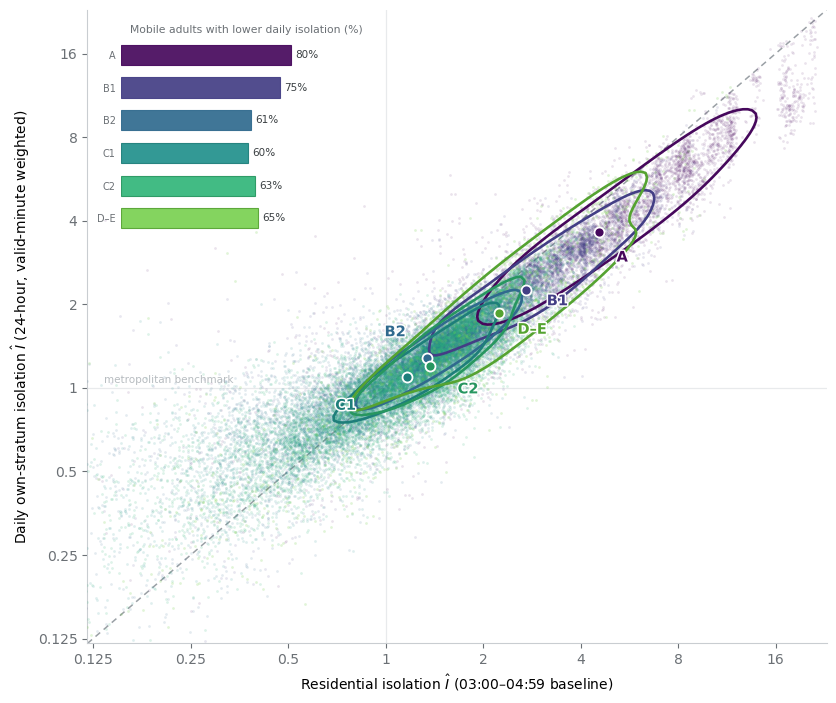

Valid paired sample: 59,966; mobile: 35,071; excluded from log plot: 298
Saved figure: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/fig_rq1_residential_vs_experienced_2023.png
Saved statistics: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/outputs/rq1_residential_vs_experienced_stats_2023.csv


,socioeconomic_stratum,mobility_status,n_unweighted,weighted_median_relative_dilution_pct,weighted_q1_relative_dilution_pct,weighted_q3_relative_dilution_pct,weighted_share_below_residential
0,A,mobile,3684,20.7,4.6,32.2,80.2%
1,A,no-trip,2013,12.6,-3.0,22.9,69.0%
2,B1,mobile,4257,15.0,-0.4,27.2,74.6%
3,B1,no-trip,2464,9.9,-0.9,18.6,73.8%
4,B2,mobile,10023,4.8,-9.1,15.9,61.2%
5,B2,no-trip,6537,4.4,-4.6,12.8,62.6%
6,C1,mobile,8577,4.3,-10.7,17.1,59.7%
7,C1,no-trip,6131,1.3,-7.0,8.5,54.7%
8,C2,mobile,6848,6.2,-7.5,20.9,63.0%
9,C2,no-trip,5840,-1.2,-9.8,6.2,45.5%


In [9]:
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import gaussian_kde


BASE = Path("/Users/mixednutgiftpack/Documents/CASA/OD2017_2023")
HOUR_FILE, DAY_FILE = [BASE / "outputs" / f for f in (
    "isolation_person_hour_2023.parquet", "isolation_person_day_2023.parquet"
)]
FIGURE_FILE = BASE / "figs/fig_rq1_residential_vs_experienced_2023.png"
STATS_FILE = BASE / "outputs/rq1_residential_vs_experienced_stats_2023.csv"

STRATA = ["A", "B1", "B2", "C1", "C2", "D–E"]
FILL = dict(zip(STRATA, ["#46085C", "#433E85", "#306A8E", "#21918C", "#32B67A", "#7AD151"]))
LINE = dict(zip(STRATA, ["#46085C", "#433E85", "#306A8E", "#1E7E7A", "#279660", "#55A331"]))
ALPHA = dict(zip(STRATA, [.11, .12, .13, .14, .16, .22]))
LABEL_OFFSET = dict(zip(STRATA, [(1.13, .78), (1.16, .88), (.74, 1.20), (.60, .76), (1.22, .80), (1.14, .84)]))
INK, LIGHT, LIMITS = "#3A3F42", "#6B7075", (.12, 23)


def check(df, cols, name):
    if missing := sorted(set(cols) - set(df)):
        raise ValueError(f"{name} is missing columns: {missing}")


def wquantile(x, w, p):
    x, w, p = np.asarray(x, float), np.asarray(w, float), np.atleast_1d(p)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not ok.any():
        return np.full(len(p), np.nan)
    x, w = x[ok], w[ok]
    order = np.argsort(x)
    x, w = x[order], w[order]
    return np.interp(p, (np.cumsum(w) - .5 * w) / w.sum(), x)


def hdr_level(z, mass=.5):
    ordered = np.sort(z.ravel())[::-1]
    return float(np.interp(mass, np.cumsum(ordered) / ordered.sum(), ordered))


def weighted_share_below(g):
    return np.average(g["isolation"] < g["residential_isolation"], weights=g["fe_pess"])


# data
def load_analysis():
    hour, day = pd.read_parquet(HOUR_FILE), pd.read_parquet(DAY_FILE)
    check(hour, ["id_pess", "hour", "isolation", "valid_minutes"], HOUR_FILE.name)
    check(day, ["id_pess", "class6", "isolation", "valid_minutes", "low_coverage", "mobile", "fe_pess"], DAY_FILE.name)
    if day["id_pess"].duplicated().any():
        raise ValueError("The person-day table must contain one row per respondent.")
    if unexpected := sorted(set(day["class6"].dropna()) - set(STRATA)):
        raise ValueError(f"Unexpected socioeconomic stratum labels: {unexpected}")

    residential = (
        hour.loc[hour.hour.isin([3, 4]) & hour.isolation.notna() & hour.valid_minutes.gt(0),
                 ["id_pess", "isolation", "valid_minutes"]]
        .assign(weighted_isolation=lambda d: d.isolation * d.valid_minutes)
        .groupby("id_pess", as_index=False)
        .agg(weighted_isolation=("weighted_isolation", "sum"),
             residential_valid_minutes=("valid_minutes", "sum"),
             residential_valid_hours=("isolation", "size"))
        .assign(residential_isolation=lambda d: d.weighted_isolation / d.residential_valid_minutes)
    )
    analysis = day.merge(
        residential[["id_pess", "residential_isolation", "residential_valid_minutes", "residential_valid_hours"]],
        on="id_pess", how="left", validate="one_to_one"
    )
    analysis = analysis.loc[
        ~analysis.low_coverage & analysis.isolation.notna() & analysis.residential_isolation.notna()
        & analysis.fe_pess.notna() & analysis.fe_pess.gt(0)
    ].copy()
    return analysis.assign(relative_dilution_pct=lambda d: (d.residential_isolation - d.isolation) / d.residential_isolation * 100)


#figure
def make_figure(analysis):
    mobile = analysis.loc[analysis.mobile].copy()
    positive = mobile.loc[mobile.isolation.gt(0) & mobile.residential_isolation.gt(0)]
    if positive.empty:
        raise ValueError("No positive mobile observations are available for the log plot.")

    fig, ax = plt.subplots(figsize=(8.4, 7.2))
    fig.subplots_adjust(left=.09, bottom=.09, right=.97, top=.97)
    ax.set(xscale="log", yscale="log", xlim=LIMITS, ylim=LIMITS)
    ax.plot(LIMITS, LIMITS, ls=(0, (4, 3)), color="#9AA0A5", lw=1.1, zorder=1)
    ax.axvline(1, color="#E8EAEC", lw=.9, zorder=0); ax.axhline(1, color="#E8EAEC", lw=.9, zorder=0)

    rng = np.random.default_rng(23)
    grid = np.linspace(np.log10(LIMITS[0]), np.log10(LIMITS[1]), 160)
    gx, gy = np.meshgrid(grid, grid)
    medians = {}
    for s in STRATA:
        g = positive.loc[positive.class6.eq(s)]
        if len(g) < 3:
            raise ValueError(f"Too few observations for the {s} KDE.")
        jitter = np.exp(rng.normal(0, .018, (2, len(g))))
        ax.scatter(g.residential_isolation * jitter[0], g.isolation * jitter[1], s=4,
                   color=FILL[s], alpha=ALPHA[s], linewidth=0, rasterized=True, zorder=3)
        kde = gaussian_kde(np.vstack([np.log10(g.residential_isolation), np.log10(g.isolation)]), weights=g.fe_pess)
        z = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
        ax.contour(10**gx, 10**gy, z, levels=[hdr_level(z)], colors=LINE[s], linewidths=1.9, zorder=5)
        medians[s] = tuple(wquantile(g[c], g.fe_pess, [.5])[0] for c in ["residential_isolation", "isolation"])
        ax.scatter(*zip(medians[s]), s=52, color=LINE[s], edgecolor="white", lw=1.3, zorder=7)

    for s, (x, y) in medians.items():
        dx, dy = LABEL_OFFSET[s]
        ax.text(x * dx, y * dy, s, color=LINE[s], fontsize=10.5, fontweight="bold", zorder=8,
                path_effects=[pe.withStroke(linewidth=2.2, foreground="white")])

    ax.text(.135, 1.04, "metropolitan benchmark", color="#B7BCC0", fontsize=7.5)

    inset = ax.inset_axes([.045, .64, .34, .32])
    for i, s in enumerate(STRATA):
        g = mobile.loc[mobile.class6.eq(s) & mobile.residential_isolation.gt(0)]
        share, y = 100 * weighted_share_below(g), len(STRATA) - 1 - i
        inset.barh(y, share, height=.62, color=FILL[s], edgecolor=LINE[s], lw=.8, alpha=.92)
        inset.text(share + 2, y, f"{share:.0f}%", va="center", fontsize=7.5, color=INK)
    inset.set(xlim=(0, 118), ylim=(-.6, 5.6), yticks=range(6), yticklabels=STRATA[::-1], xticks=[])
    inset.set_title("Mobile adults with lower daily isolation (%)", fontsize=7.8, color=LIGHT, pad=2)
    inset.tick_params(length=0, labelsize=7, colors=LIGHT)
    inset.set_facecolor("none"); [sp.set_visible(False) for sp in inset.spines.values()]

    ticks = [.125, .25, .5, 1, 2, 4, 8, 16]
    ax.set(xlabel=r"Residential isolation $\hat{I}$ (03:00–04:59 baseline)",
           ylabel=r"Daily own-stratum isolation $\hat{I}$ (24-hour, valid-minute weighted)",
           xticks=ticks, yticks=ticks, xticklabels=map(str, ticks), yticklabels=map(str, ticks))
    ax.minorticks_off(); ax.tick_params(colors=LIGHT)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#C9CDD1")
    return fig, mobile, positive



def make_statistics(analysis):
    rows = []
    for s in STRATA:
        for label, is_mobile in [("mobile", True), ("no-trip", False)]:
            g = analysis.loc[analysis.class6.eq(s) & analysis.mobile.eq(is_mobile) & analysis.residential_isolation.gt(0)]
            q10, q1, median, q3, q90 = wquantile(g.relative_dilution_pct, g.fe_pess, [.10, .25, .50, .75, .90])
            rows.append(dict(socioeconomic_stratum=s, mobility_status=label, n_unweighted=len(g),
                             weighted_median_relative_dilution_pct=median,
                             weighted_q1_relative_dilution_pct=q1,
                             weighted_q3_relative_dilution_pct=q3,
                             weighted_share_below_residential=weighted_share_below(g)))
    return pd.DataFrame(rows)


analysis = load_analysis()
figure, mobile, positive_mobile = make_figure(analysis)
statistics = make_statistics(analysis)
statistics.to_csv(STATS_FILE, index=False)
figure.savefig(FIGURE_FILE, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Valid paired sample: {len(analysis):,}; mobile: {len(mobile):,}; excluded from log plot: {len(mobile)-len(positive_mobile):,}")
print(f"Saved figure: {FIGURE_FILE}\nSaved statistics: {STATS_FILE}")
display(statistics.style.format({c: "{:.1f}" for c in statistics if "dilution_pct" in c}
                                | {"weighted_share_below_residential": "{:.1%}"}))
